In [1]:
import torch
import numpy as np
import pandas as pd
import networkx as nx
from tqdm import tqdm
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score
from collections import defaultdict 
from poincare import PoincareManifold
from model import Distance_PE
from data import G_hpo
from frechetmean import frechet_mean

In [2]:
# Modifier à chaque fois :
checkpoint = torch.load('logs/2026_5_7/12/model_final.pt', map_location='cpu', weights_only=False)

objects = checkpoint['objects']
node2id = checkpoint['node2id']
losses = checkpoint['losses']
norm_history = checkpoint['norm_history']
edges_closed = checkpoint['edges']
data = checkpoint['data']
hp = checkpoint['hyperparams']

edges = np.array([(node2id[u], node2id[v]) for u, v in G_hpo.edges()],dtype=np.int64)


In [3]:
print(hp)

{'dim': 15, 'epochs': 1500, 'lr': 1.6, 'burnin': 100, 'n_neg': 100}


In [4]:
manifold = PoincareManifold()
model = Distance_PE(n=len(objects), dim=hp['dim'],
                       manifold=manifold, sparse=False, learn_curvature=False, init_curvature=1., weight_decay=0)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Distance_PE(
  (embeddings): Embedding(19389, 15)
)

In [5]:
W = model.weight.detach().cpu().numpy()   # (N, dim)
norms = np.linalg.norm(W, axis=1)

print(f"Modèle chargé — {len(objects)} nœuds | dim={hp['dim']} | "
      f"{len(losses)} epochs")
print(f"Norme moy={norms.mean():.4f} | max={norms.max():.4f}")

i_min = np.argmin(norms).item()
print(f"Index de la plus petite norme : {i_min}")
print(f"Position du point : {W[i_min]}")


Modèle chargé — 19389 nœuds | dim=15 | 1500 epochs
Norme moy=0.9640 | max=0.9900
Index de la plus petite norme : 101
Position du point : [-0.02290159  0.00820978 -0.00655441  0.00533598 -0.02455972 -0.06093883
 -0.00785416  0.03578258 -0.01433282  0.04514984  0.00592283 -0.01020399
 -0.04606588  0.02117609  0.04252743]


In [6]:
degrees = np.array([len(data.pos_neighbors[i]) for i in range(len(objects))])
norms = model.weight.detach().norm(dim=-1).numpy()

# Corrélation degré/norme attendue : négative
rho, pval = spearmanr(degrees, norms)
print(f"Corrélation Spearman degré/norme : {rho:.3f} (p={pval:.2e})")

Corrélation Spearman degré/norme : 0.196 (p=8.50e-168)


In [7]:
pos_neighbors = defaultdict(set)
pos_parents = defaultdict(set)

for u, v in edges:
    pos_neighbors[int(u)].add(int(v))
    pos_parents[int(v)].add(int(u))
    
len(pos_parents[i_min])
len(pos_parents[0])

7

In [8]:
degrees = np.array([len(data.pos_neighbors[i]) for i in range(len(objects))])

# Top 10 plus proches du centre
center_ids = np.argsort(norms)[:10]
print("=== 10 nœuds les plus proches du CENTRE ===")
for i in center_ids:
    print(f"  {objects[i]:<30} norme={norms[i]:.4f}  degré={degrees[i]}")

# Top 10 plus proches du bord
border_ids = np.argsort(norms)[-10:]
print("\n=== 10 nœuds les plus proches du BORD ===")
for i in border_ids:
    print(f"{objects[i]:<30} norme={norms[i]:.4f}  degré={degrees[i]}")

=== 10 nœuds les plus proches du CENTRE ===
  HP:0000118                     norme=0.1144  degré=1
  HP:0000001                     norme=0.1300  degré=0
  HP:0012649                     norme=0.2559  degré=1
  HP:0001939                     norme=0.2987  degré=1
  HP:0000163                     norme=0.3659  degré=1
  HP:0000818                     norme=0.4590  degré=1
  HP:0011793                     norme=0.4630  degré=1
  HP:0012823                     norme=0.4656  degré=1
  HP:0012638                     norme=0.4680  degré=1
  HP:0011001                     norme=0.4913  degré=1

=== 10 nœuds les plus proches du BORD ===
HP:0009509                     norme=0.9900  degré=3
HP:0009632                     norme=0.9900  degré=4
HP:0009535                     norme=0.9900  degré=2
HP:0009517                     norme=0.9900  degré=3
HP:0009529                     norme=0.9900  degré=3
HP:0009533                     norme=0.9900  degré=3
HP:0009669                     norme=0.9900  

In [9]:
@torch.no_grad()
def evaluate(model, objects, edges, node2id):
    model.eval()
    W = model.weight.to(device)
    pos_neighbors = defaultdict(set)
    for u, v in edges:
        pos_neighbors[int(u)].add(int(v))

    ranksum, ap_scores = 0, 0
    nranks = 0
    iters = 0
    labels = np.empty(model.embeddings.weight.size(0))
 
    for u in tqdm(objects):
        labels.fill(0)
        u = int(node2id[u])
        neighbors = pos_neighbors.get(u, set())
        if not neighbors :
            continue
        u_exp = W[u].unsqueeze(0).expand(W.shape[0], -1)  # Coordonnées de u dans la boule de Poincaré
        dists = manifold.distance(u_exp, W, 1).numpy()  # Distance de Poincaré de u aux autres noeuds
        dists[u] = 1e12
        #order = np.argsort(dists)  # Tri par distance décroissante p/r à u
        sorted_ind = np.argsort(dists)

        #ranks = int(np.where(order == v)[0][0]) + 1  # Rang du noeud v p/r à u dans l'embedding
        #ranks.append(rank)
        ranks, = np.where(np.isin(sorted_ind, list(neighbors)))
        ranks += 1
        N = ranks.shape[0]

        ranksum += ranks.sum() - (N * (N - 1) / 2)
        nranks += ranks.shape[0]
        labels[list(neighbors)] = 1
        ap_scores += average_precision_score(labels, -dists)
        iters += 1

        #pos  = pos_neighbors[u]  # Voisins de u dans la représentation initiale
        #hits, psum = 0, 0.0 
        #for k, idx in enumerate(order[1:], 1):  # On parcourt les noeuds du plus proche au plus éloigné
            #if idx in pos:
                #hits  += 1
                #psum  += hits / k
        #aps.append(psum / max(len(pos), 1))
 
    return float(ranksum), nranks, ap_scores, iters

In [10]:
objects_hpo = list(G_hpo.nodes())
node2id_hpo = {n: i for i, n in enumerate(objects_hpo)}
edges_hpo = np.array([(node2id_hpo[v], node2id_hpo[u]) for u, v in G_hpo.edges()],dtype=np.int64)
new_edges = [(v, u) for u, v in edges]
results = evaluate(model.weight.detach().cpu(), objects, new_edges, node2id)

print("Erreur moyenne sur le rang : ", float(results[0]) / results[1])
print("Mean Average Precision :", float(results[2]) / results[3])

AttributeError: 'Tensor' object has no attribute 'eval'

In [11]:
@torch.no_grad()
def evaluate2(model, objects, edges, node2id, device):
    """
    Retourne MAP et mean rank.
    Corrige : distance avec model.c, calcul GPU, pas de fuite u dans le ranking.
    """
    model.eval()
    W = model.weight.to(device)  # (N, dim)

    pos_neighbors = defaultdict(set)
    for u, v in edges:
        pos_neighbors[int(u)].add(int(v))

    ap_scores = []
    ranks_all = []
    N = W.shape[0]
    labels = np.zeros(N)

    for obj in tqdm(objects):
        u = int(node2id[obj])
        neighbors = pos_neighbors.get(u, set())
        if not neighbors:
            continue

        # Distances GPU avec la bonne courbure
        u_emb = W[u].unsqueeze(0).expand(N, -1)   # (N, dim)
        dists = model.manifold.distance(u_emb, W, model.c)  # (N,)
        dists[u] = float('inf')                    # exclure u lui-même
        dists_np = dists.cpu().numpy()

        max_finite = dists_np[np.isfinite(dists_np)].max()
        dists_np[~np.isfinite(dists_np)] = max_finite + 1.0

        # Rang des voisins
        sorted_ind = np.argsort(dists_np)
        ranks = np.where(np.isin(sorted_ind, list(neighbors)))[0] + 1
        # Correction : soustraire les rangs des autres voisins placés avant
        n_neighbors = len(neighbors)
        corrected_ranks = ranks - np.arange(n_neighbors)
        ranks_all.extend(corrected_ranks.tolist())

        # AP
        labels.fill(0)
        labels[list(neighbors)] = 1
        ap_scores.append(average_precision_score(labels, -dists_np))

    map_score  = float(np.mean(ap_scores))
    mean_rank  = float(np.mean(ranks_all))

    model.train()
    return map_score, mean_rank

In [13]:
results = evaluate2(model, objects, new_edges, node2id, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))

results

100%|██████████| 19389/19389 [00:30<00:00, 627.74it/s] 


(0.7653385461399612, 411.49415044135657)

In [14]:
print("min", norms.min(), "moy", norms.mean(), "max", norms.max())

min 0.11438677 moy 0.96395105 max 0.99000007


## Calcul de l'*information content* (des poids pour les barycentres)

In [12]:
profils_omim = pd.read_csv("../data/profils_omim.csv.gz", index_col=0)
profils_omim = profils_omim.reset_index()

/tmp/ipykernel_1867/2817799710.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


In [13]:
import re

hp_ids = []
parents_list = []

with open("../data/HPOs.csv", "r") as f:
    next(f)
    for line in f:
        hp_id = line.split(';')[0]
        
        # Extraire uniquement la liste contenant des IDs HP:XXXXXXX
        match = re.search(r"\[([^\]]*'HP:\d{7}'[^\]]*)\]", line)
        if match:
            parents = re.findall(r"HP:\d{7}", match.group(0))
        else:
            parents = []
        
        hp_ids.append(hp_id)
        parents_list.append(parents)

df_hpo = pd.DataFrame({'hp_id': hp_ids, 'parents': parents_list})

# Vérification
print(repr(df_hpo['hp_id'].iloc[1]))
print(df_hpo['parents'].iloc[1])
print(df_hpo['parents'].iloc[7])

'HP:0000002'
['HP:0001507']
['HP:0000014']


In [14]:
G_hpo_work = nx.DiGraph()
for hp_id in hp_ids:
    G_hpo_work.add_node(hp_id)
for hp_id, parents in zip(hp_ids, parents_list):
    for parent_id in parents:
        if parent_id in G_hpo_work:
            G_hpo_work.add_edge(hp_id, parent_id)

objects_w = list(G_hpo_work.nodes())
node2id_w = {n: i for i, n in enumerate(objects)}

# Vérification
print([repr(n) for n in list(G_hpo_work.nodes)[:3]])
print("Ancêtres HP:6001462:", list(nx.ancestors(G_hpo_work, 'HP:6001462')))

["'HP:0000001'", "'HP:0000002'", "'HP:0000003'"]
Ancêtres HP:6001462: []


In [15]:
deprecated={
    'HP:0006887':'HP:0001249',
    'HP:0002275':'HP:0002311',
    'HP:0002370':'HP:0002311',
    'HP:0002438':'HP:0001317',
    'HP:0004059':'HP:0006433',
    'HP:0005365':'HP:0010976',
    'HP:0005435':'HP:0011840',
    'HP:0005807':'HP:0009881',
    'HP:0007543':'HP:0000962',
    'HP:0007680':'HP:0007894',
    'HP:0007850':'HP:0030666',
    'HP:0007898':'HP:0012231',
    'HP:0009062':'HP:0008936',
    'HP:0010064':'HP:0010091',
    'HP:0012178':'HP:0012177',
    'HP:0030050':'HP:0002524',  # Suspect
    'HP:0031014':'HP:0031632',
    'HP:0100786':'HP:0001262',
    'HP:0200065':'HP:0000533'
}

def get_ancestors0(G, node):
    visited = set()
    queue = list(G.successors(node))
    while queue:
        current = queue.pop()
        if current not in visited:
            visited.add(current)
            queue.extend(G.successors(current))
    return visited

# Test
print(get_ancestors0(G_hpo_work, 'HP:0000253'))
# doit donner {HP:0005484, HP:0000252, ..., HP:0000001}

def compute_information_content(df_omim, G_hpo, deprecated):
    colnames = df_omim.columns[1:]
    weights = defaultdict(float)
    diseases = defaultdict(set)
    all_diseases = defaultdict(set)
    ancestors = {}

    def get_ancestors(term):
        if term not in ancestors:
            ancestors[term]=get_ancestors0(G_hpo, term)
        return ancestors[term]

    for id, row in df_omim.iterrows():
        for term in colnames:
            if row[term]==1:
                resolved = deprecated.get(term, term)
                weights[resolved]+=1
                diseases[resolved].add(id)
                all_diseases[resolved].add(id)
                for ancestor in get_ancestors(resolved):
                    weights[ancestor]+=1
                    all_diseases[ancestor].add(id)
    total = sum(weights.values())
    return {t: w / total for t, w in weights.items()}, diseases, all_diseases


{'HP:0000929', 'HP:0000924', 'HP:0000152', 'HP:0000240', 'HP:0002060', 'HP:0000118', 'HP:0011842', 'HP:0000234', 'HP:0033127', 'HP:0009121', 'HP:0000252', 'HP:0012443', 'HP:0100547', 'HP:0000001', 'HP:0002011', 'HP:0012639', 'HP:0005484', 'HP:0040195', 'HP:0007364', 'HP:0000707', 'HP:0002977'}


In [16]:
hpo_cols = [col for col in profils_omim.columns if col.startswith("HP:")]
manquants = [col for col in hpo_cols if col not in G_hpo]
print(f"{len(manquants)} termes absents du graphe : {manquants}")

19 termes absents du graphe : ['HP:0002275', 'HP:0002370', 'HP:0002438', 'HP:0004059', 'HP:0005365', 'HP:0005435', 'HP:0005807', 'HP:0006887', 'HP:0007543', 'HP:0007680', 'HP:0007850', 'HP:0007898', 'HP:0009062', 'HP:0010064', 'HP:0012178', 'HP:0030050', 'HP:0031014', 'HP:0100786', 'HP:0200065']


In [17]:
weights, diseases, all_diseases = compute_information_content(profils_omim, G_hpo_work, deprecated)

In [18]:
# Vérification
sum(weights.values())

1.0

In [19]:
def inspect_weights(weights, disease, all_disease, G_hpo, top_n=20):
    roots = [n for n in G_hpo.nodes if G_hpo.out_degree(n) == 0]
    root = roots[0] if roots else None

    G_inv = G_hpo.reverse()
    if root:
        depths = nx.single_source_shortest_path_length(G_inv, root)
    else:
        depths = {}

    rows = []
    for term, weight in weights.items():
        n_ancestors = len(get_ancestors0(G_hpo, term))
        n_children  = G_hpo.in_degree(term)
        rows.append({
            'term'       : term,
            'weight'     : weight,
            'depth'      : depths.get(term, -1),
            'n_ancestors': n_ancestors,
            'n_children' : n_children,
            'n_diseases' : len(disease.get(term, set())) if term in disease else 0,
            'n_diseases tot':len(all_disease.get(term, set())) if term in all_disease else 0
        })

    df = (pd.DataFrame(rows)
            .sort_values('weight', ascending=False)
            .reset_index(drop=True))

    df.index += 1
    df['weight'] = df['weight'].map('{:.6f}'.format)

    print(f"Racine détectée : {root}")
    print(f"Termes : {len(weights)}\n")
    print(df.head(top_n).to_string())
    return df

df_inspect = inspect_weights(weights, diseases, all_diseases, G_hpo_work, top_n=20)

Racine détectée : HP:0000001
Termes : 5674

          term    weight  depth  n_ancestors  n_children  n_diseases  n_diseases tot
1   HP:0000118  0.139856      1            1          23        6139            6139
2   HP:0000001  0.139856      0            0           7           0            6139
3   HP:0000707  0.033079      2            2           3        3877            3936
4   HP:0033127  0.030582      2            2           4        3798            3882
5   HP:0000924  0.021063      3            3           4        3005            3106
6   HP:0012638  0.020213      3            3          28        3581            3627
7   HP:0011842  0.019454      4            4          23        2899            2986
8   HP:0000152  0.016285      2            2           2        2828            3072
9   HP:0000234  0.015033      3            3           6        2781            3029
10  HP:0040064  0.011963      2            2          14        2184            2204
11  HP:0012639  0.011

'*HP:0000001*' correspond à la racine (et n'est pas présent dans `profils_omim`) et '*HP:0000118*' correspond à la catégorie *Phenotypic abnormality*, il est donc cohérent qu'elles aient les comptes les plus élevés, égaux au nombre de maladies.

## Représentation des maladies dans l'embeddings

On souhaite d'abord :
- visualiser pour une maladie les termes HPO dans l'*embedding* obtenu ;
- avoir une métrique résumant à quel point les termes HPO d'une même maladies sont éloignés les uns des autres dans l'*embedding* obtenu.

Dans un second temps, on calculera le barycentre des termes HPO pour chaque maladie, afin d'avoir une représentation synthétique de ces dernières, en pondérant :
- soit uniformément ;
- soit avec l'inverse des poids calculés précédemment (*information content*).

In [20]:
def f_active_terms(row, hpo_cols, node2id, deprecated):
    active=[]
    for term in hpo_cols:
        if row[term]==1:
            resolved = deprecated.get(term, term)
            if resolved in node2id:
                active.append(resolved)
    return active

In [21]:
from itertools import combinations

def disease_hpo_distances(disease_id, profils_omim, node2id, deprecated=deprecated):

    row = profils_omim.loc[disease_id]
    hpo_cols = profils_omim.columns[1:]
    active_terms = f_active_terms(row, hpo_cols, node2id, deprecated)

    if len(active_terms) < 2:
        print(f"Strictement moins de 2 termes HPO pour {disease_id}")
        return None
    model.eval()
    W = model.weight.detach().cpu().numpy()
    embs = np.array([W[node2id[t]] for t in active_terms])

    # Calculer toutes les distances par paires
    pairs = list(combinations(range(len(active_terms)), 2))
    distances = {}
    manifold=PoincareManifold()
    for i, j in pairs:
        u = torch.tensor(embs[i], dtype=torch.float64)
        v = torch.tensor(embs[j], dtype=torch.float64)
        d = manifold.distance(u, v, c=1).item()
        distances[(active_terms[i], active_terms[j])] = d

    dist_values = np.array(list(distances.values()))

    stats = {
        'disease'   : disease_id,
        'n_terms'   : len(active_terms),
        'mean_dist' : dist_values.mean(),
        'max_dist'  : dist_values.max(),
        'min_dist'  : dist_values.min(),
        'std_dist'  : dist_values.std(),
    }

    return active_terms, embs, distances, stats

In [22]:
# Exemple
active_terms, embs, distances, stats = disease_hpo_distances(3, profils_omim, node2id_w)
stats

{'disease': 3,
 'n_terms': 55,
 'mean_dist': np.float64(5.523257728965684),
 'max_dist': np.float64(9.16883064934852),
 'min_dist': np.float64(0.00031792342844160594),
 'std_dist': np.float64(1.8059151205052413)}

In [ ]:
def compute_all_distances(profils_omim, node2id, deprecated=deprecated):
    hpo_cols = profils_omim.columns[1:]
    results = []

    model.eval()
    W = model.weight.detach().cpu().numpy()
    manifold=PoincareManifold()

    col_to_idx = {}
    for col in hpo_cols:
        resolved = deprecated.get(col, col)
        if resolved in node2id:
            col_to_idx[col] = node2id[resolved]

    valid_cols = [col for col in hpo_cols if col in col_to_idx]
    col_ids = torch.tensor([col_to_idx[col] for col in valid_cols], dtype=torch.long)

    M = torch.tensor(profils_omim[valid_cols].values, dtype=torch.bool)
    E = W[col_ids]

    names = profils_omim.iloc[:, 0].tolist()
    print(names)

    for (disease_id, name), row_mask in tqdm(zip(zip(profils_omim.index, names), M),total=len(profils_omim)):
        idx = row_mask.nonzero(as_tuple=True)[0]
        if len(idx) < 2:
            continue
        embs = E[idx]
        n = len(embs)
        ii, jj = torch.triu_indices(n, n, offset=1)
        dists = manifold.distance(torch.tensor(embs[ii], dtype=torch.float64), torch.tensor(embs[jj], dtype=torch.float64), c=1.)
        dists = np.array(dists)
        results.append({
            'disease': disease_id,
            'name': name,
            'n_terms': n,
            'sum': dists.sum(),
            'mean_dist': dists.mean(),
            'max_dist': dists.max(),
            'min_dist': dists.min(),
            'std_dist': dists.std(),
        })

    return pd.DataFrame(results).reset_index(drop=True)

omim_distances = compute_all_distances(profils_omim, node2id_w)
omim_distances.to_csv("../data/omim_distances.csv", index=False)        

In [28]:
omim_distances

,disease,name,n_terms,sum,mean_dist,max_dist,min_dist,std_dist
0,0,A2ML1 (OMIM:166760),13,300.884678,3.857496,7.323423,1.287150e-01,1.675518
1,1,AAAS (OMIM:231550),115,33970.446279,5.182372,9.042595,3.895778e-04,1.518574
2,2,AAGAB (OMIM:148600),29,1729.555481,4.259989,7.937260,1.000001e-03,1.431579
3,3,AARS1 (OMIM:613287),55,8202.037728,5.523258,9.168831,3.179234e-04,1.805915
4,4,AARS1 (OMIM:616339),85,17708.942870,4.960488,8.801507,2.202673e-04,1.507739
...,...,...,...,...,...,...,...,...
6134,6134,ZPR1 (OMIM:619321),163,63330.897162,4.796705,8.897574,1.018500e-04,1.371434
6135,6135,ZSWIM6 (OMIM:603671),195,95637.950885,5.056196,8.859855,2.000000e-10,1.436542
6136,6136,ZSWIM6 (OMIM:617865),129,42740.203060,5.176866,8.789157,1.663035e-04,1.442863
6137,6137,ZSWIM7 (OMIM:619831),16,573.608117,4.780068,7.385514,8.031496e-04,1.988567


In [24]:
def compute_disease_barycenters(profils_omim,node2id, deprecated=deprecated, weights=None, normalize=False, c=1):
    
    model.eval()
    W = model.weight.detach().cpu()

    hpo_cols = profils_omim.columns[1:]

    col_meta = {}
    for col in hpo_cols:
        resolved = deprecated.get(col, col)
        if resolved in node2id:
            w = weights[resolved] if (weights is not None and resolved in weights) else 1.0
            col_meta[col]=(W[node2id[resolved]], w)

    valid_cols = list(col_meta.keys())

    barycenters = []
    for _, row in tqdm(profils_omim.iterrows(), total=len(profils_omim), desc="Barycentres"):
        active = [(col_meta[col][0], col_meta[col][1])
                  for col in valid_cols if row[col] == 1]

        if len(active) < 1:
            barycenters.append(None)
            continue

        points  = torch.stack([a[0] for a in active])
        if weights is None:
            w = None
        else:
            w = torch.tensor([a[1] for a in active], dtype=torch.float32)
            if normalize:
                w = w / w.sum()
 
        barycenter = frechet_mean(points,c, w)
        barycenters.append(barycenter.numpy())

    profils_omim['barycenter'] = barycenters
    return profils_omim
 

In [25]:
profils_test = profils_omim.copy()
profils_test = compute_disease_barycenters(profils_test, node2id_w)

Barycentres: 100%|██████████| 6139/6139 [01:54<00:00, 53.57it/s]


In [26]:
inv_weights = {t: 1/w for t, w in weights.items()}
profils_test_weight = profils_omim.copy()
profils_test_weight = compute_disease_barycenters(profils_test_weight, node2id_w, deprecated, inv_weights)

Barycentres: 100%|██████████| 6139/6139 [01:49<00:00, 56.22it/s]


In [27]:
profils_test_norm = profils_omim.copy()
profils_test_norm = compute_disease_barycenters(profils_test_norm, node2id_w, deprecated, weights=inv_weights, normalize=True)

Barycentres: 100%|██████████| 6139/6139 [01:56<00:00, 52.82it/s]


In [28]:
def verif_barycenter(profils_omim, deprecated, node2id):
    model.eval()
    W = model.weight.detach().cpu()

    bary_matrix = np.stack(profils_omim['barycenter'].dropna().values)
    norms = np.linalg.norm(bary_matrix, axis=1)
    print(f"Normes — min: {norms.min():.4f} | moy: {norms.mean():.4f} | max: {norms.max():.4f}")
    disease_id = 3
    row = profils_omim.loc[disease_id]
    hpo_cols = [col for col in profils_omim.columns if col.startswith('HP:')]
    active = [col for col in hpo_cols if row[col] == 1 and deprecated.get(col, col) in node2id]
    embs = torch.stack([W[node2id[deprecated.get(t, t)]] for t in active])
    bary = torch.tensor(row['barycenter'])

    print(f"\nMaladie {disease_id} — {len(active)} termes actifs")
    print(f"Norme (euclidienne) moyenne des termes : {embs.norm(dim=1).mean():.4f}")
    print(f"Norme (euclidienne) du barycentre : {bary.norm():.4f}")

verif_barycenter(profils_test, deprecated, node2id_w)
verif_barycenter(profils_test_norm, deprecated, node2id_w)
verif_barycenter(profils_test_weight, deprecated, node2id_w)


Normes — min: 0.1371 | moy: 0.5577 | max: 0.8702

Maladie 3 — 55 termes actifs
Norme (euclidienne) moyenne des termes : 0.8677
Norme (euclidienne) du barycentre : 0.6617
Normes — min: 0.2844 | moy: 0.9167 | max: 0.9837

Maladie 3 — 55 termes actifs
Norme (euclidienne) moyenne des termes : 0.8677
Norme (euclidienne) du barycentre : 0.9255
Normes — min: 0.2844 | moy: 0.9167 | max: 0.9837

Maladie 3 — 55 termes actifs
Norme (euclidienne) moyenne des termes : 0.8677
Norme (euclidienne) du barycentre : 0.9255


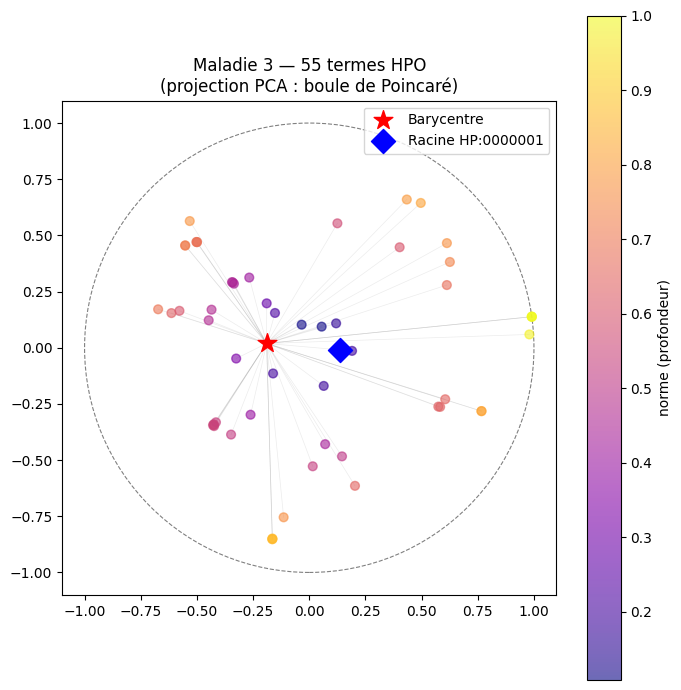

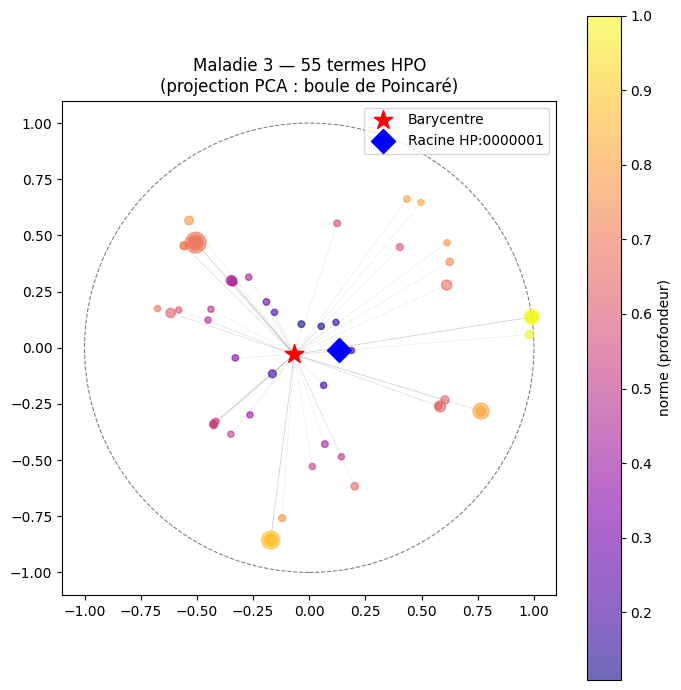

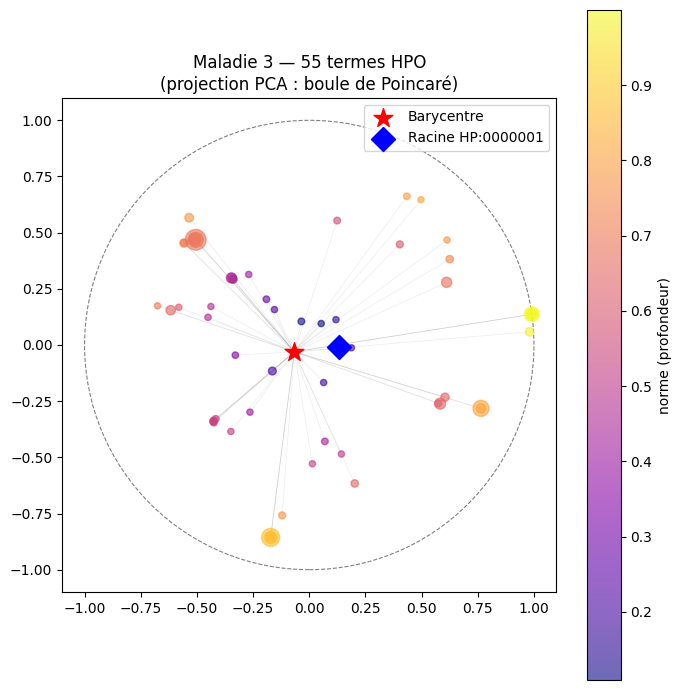

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.decomposition import PCA

def visualize_barycenter(profils_omim, node2id, deprecated, weights=None, disease_id=3):
    model.eval()
    W = model.weight.detach().cpu().numpy()

    row = profils_omim.loc[disease_id]
    hpo_cols = [col for col in profils_omim.columns if col.startswith('HP:')]
    active = [col for col in hpo_cols if row[col] == 1 and deprecated.get(col, col) in node2id]

    embs = np.stack([W[node2id[deprecated.get(t, t)]] for t in active])
    bary = row['barycenter']
    root = W[node2id['HP:0000001']]

    # PCA dans l'espace ambiant sur les termes actifs + barycentre + racine
    all_points = np.vstack([embs, bary, root])
    pca = PCA(n_components=2)
    projected = pca.fit_transform(all_points)

    embs_2d = projected[:-2]
    bary_2d = projected[-2]
    root_2d = projected[-1]

    # Normaliser pour rester dans la boule unité visuellement
    max_norm = np.linalg.norm(projected, axis=1).max()
    embs_2d = embs_2d / max_norm
    bary_2d = bary_2d / max_norm
    root_2d = root_2d / max_norm

    # Poids pour la taille des points
    if weights is not None:
        sizes = np.array([weights.get(deprecated.get(t, t), 1e-4) for t in active])
        sizes = 20 + 200 * (sizes - sizes.min()) / (sizes.max() - sizes.min() + 1e-10)
    else:
        sizes = np.full(len(active), 40)

    fig, ax = plt.subplots(figsize=(7, 7))

    # Boule de Poincaré
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=0.8)
    ax.add_patch(circle)

    # Termes actifs
    sc = ax.scatter(embs_2d[:, 0], embs_2d[:, 1], s=sizes, alpha=0.6,
                    c=np.linalg.norm(embs_2d, axis=1), cmap='plasma', zorder=3)

    # Lignes vers le barycentre
    for pt in embs_2d:
        ax.plot([pt[0], bary_2d[0]], [pt[1], bary_2d[1]],
                color='gray', alpha=0.15, linewidth=0.5, zorder=2)

    # Barycentre
    ax.scatter(*bary_2d, s=200, c='red', marker='*', zorder=5, label='Barycentre')

    # Racine
    ax.scatter(*root_2d, s=150, c='blue', marker='D', zorder=5, label='Racine HP:0000001')

    plt.colorbar(sc, ax=ax, label='norme (profondeur)')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.legend()
    ax.set_title(f"Maladie {disease_id} — {len(active)} termes HPO\n(projection PCA : boule de Poincaré)")
    plt.tight_layout()
    plt.show()

visualize_barycenter(profils_test,node2id_w, deprecated)
visualize_barycenter(profils_test_norm, node2id_w, deprecated, weights=inv_weights)
visualize_barycenter(profils_test_weight, node2id_w, deprecated, weights=inv_weights)

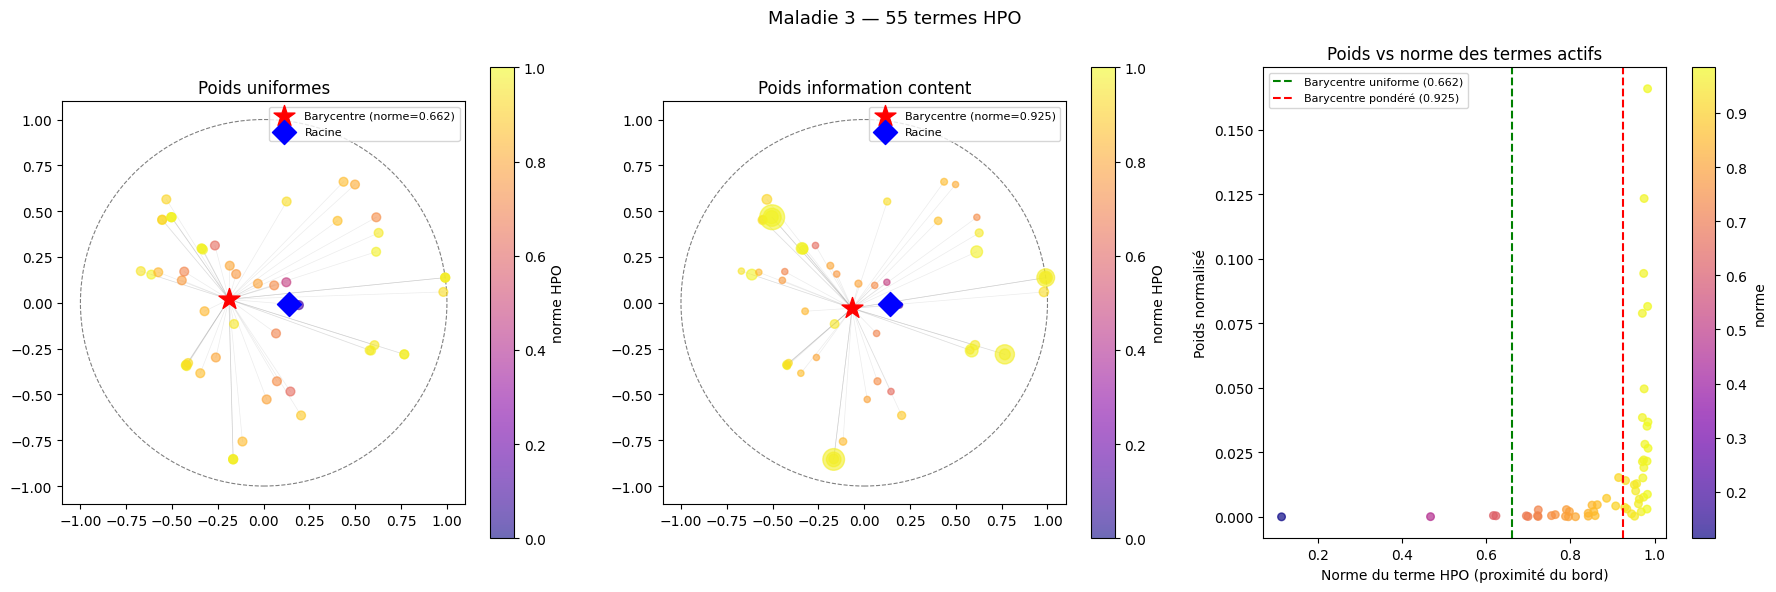

In [36]:
def compare_barycenters(profils_uniform, profils_weighted, model, node2id, deprecated, weights, disease_id=3):
    model.eval()
    W = model.weight.detach().cpu().numpy()

    row = profils_uniform.loc[disease_id]
    hpo_cols = [col for col in profils_uniform.columns if col.startswith('HP:')]
    active = [col for col in hpo_cols if row[col] == 1 and deprecated.get(col, col) in node2id]

    embs = np.stack([W[node2id[deprecated.get(t, t)]] for t in active])
    bary_uni = profils_uniform.loc[disease_id, 'barycenter']
    bary_w = profils_weighted.loc[disease_id, 'barycenter']
    root = W[node2id['HP:0000001']]

    # PCA commune pour les deux plots
    all_points = np.vstack([embs, bary_uni, bary_w, root])
    pca = PCA(n_components=2)
    proj = pca.fit_transform(all_points)
    max_norm = np.linalg.norm(proj, axis=1).max()
    proj = proj / max_norm

    embs_2d = proj[:-3]
    bary_uni2d = proj[-3]
    bary_w2d = proj[-2]
    root_2d = proj[-1]

    norms = np.linalg.norm(embs, axis=1)
    w_vals = np.array([weights.get(deprecated.get(t, t), 1e-6) for t in active])
    w_norm = w_vals / w_vals.sum()
    sizes_w = 20 + 300 * w_norm / w_norm.max()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, bary_2d, bary_arr, title, sizes in zip(
        axes[:2],
        [bary_uni2d, bary_w2d],
        [bary_uni,   bary_w],
        ['Poids uniformes', 'Poids information content'],
        [np.full(len(active), 40), sizes_w]
    ):
        circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=0.8)
        ax.add_patch(circle)

        sc = ax.scatter(embs_2d[:, 0], embs_2d[:, 1],
                        s=sizes, alpha=0.6,
                        c=norms, cmap='plasma', vmin=0, vmax=1, zorder=3)

        for pt in embs_2d:
            ax.plot([pt[0], bary_2d[0]], [pt[1], bary_2d[1]],
                    color='gray', alpha=0.15, linewidth=0.5, zorder=2)

        ax.scatter(*bary_2d, s=250, c='red',  marker='*', zorder=5,
                   label=f'Barycentre (norme={np.linalg.norm(bary_arr):.3f})')
        ax.scatter(*root_2d, s=150, c='blue', marker='D', zorder=5, label='Racine')

        plt.colorbar(sc, ax=ax, label='norme HPO')
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect('equal')
        ax.legend(fontsize=8)
        ax.set_title(title)

    # Panneau 3 : distribution des normes colorée par poids
    ax3 = axes[2]
    sc3 = ax3.scatter(norms, w_norm, c=norms, cmap='plasma', s=30, alpha=0.7)
    ax3.axvline(np.linalg.norm(bary_uni), color='green',  linestyle='--',
                label=f'Barycentre uniforme ({np.linalg.norm(bary_uni):.3f})')
    ax3.axvline(np.linalg.norm(bary_w),   color='red',    linestyle='--',
                label=f'Barycentre pondéré ({np.linalg.norm(bary_w):.3f})')
    ax3.set_xlabel('Norme du terme HPO (proximité du bord)')
    ax3.set_ylabel('Poids normalisé')
    ax3.set_title('Poids vs norme des termes actifs')
    ax3.legend(fontsize=8)
    plt.colorbar(sc3, ax=ax3, label='norme')

    fig.suptitle(f'Maladie {disease_id} — {len(active)} termes HPO', fontsize=13)
    plt.tight_layout()
    plt.show()

compare_barycenters(profils_test, profils_test_weight, model, node2id_w, deprecated, inv_weights)

## Chargement des profils ORPHA

On souhaite d'abord vérifier si la représentation via les *embeddings* permet d'obtenir de meilleurs plans de transport qu'auparavant, avec la distance de Jaccard. En particulier, on dispose de deux représentations des maladies : des barycentres pondérés uniformément ou bien pondérés par l'*information content*. On réalise d'abord le transport entre les maladies des bases OMIM et ORPHA. On aimerait que chaque maladie de la première base soit transportée le plus fidèlement sur la maladie correspondante dans la seconde base.

In [29]:
profils_orpha = pd.read_csv("../data/target_orpha_matrix.csv", index_col=0)
profils_orpha = profils_orpha.reset_index()
profils_orpha.head()

/tmp/ipykernel_1867/4227213603.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_orpha = profils_orpha.reset_index()


,database_id,HP:0000002,HP:0000003,HP:0000008,HP:0000009,HP:0000010,HP:0000011,HP:0000012,HP:0000013,HP:0000015,...,HP:6000361,HP:6000572,HP:6000578,HP:6000623,HP:6000642,HP:6000748,HP:6000976,HP:6001074,HP:6001185,gene
0,ORPHA:100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ATM
1,ORPHA:1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AP3D1
2,ORPHA:100006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,APP
3,ORPHA:100008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CST3
4,ORPHA:100050,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SERPING1


In [30]:
def read_hpoa(path):
    with open(path, 'r') as f:
        skip = sum(1 for line in f if line.startswith('#'))
    return pd.read_csv(path, sep='\t', skiprows=skip, low_memory=False)

df_hpoa = read_hpoa('../data/phenotype_omim_orpha.hpoa')
df_hpoa['disease_name'] =df_hpoa['disease_name'].str.lower().str.strip().str.replace(r'[\s\-]+', ' ', regex=True)
df_hpoa.tail()

,database_id,disease_name,qualifier,hpo_id,reference,evidence,onset,frequency,sex,modifier,aspect,biocuration
282718,ORPHA:1777,temtamy syndrome,NaN,HP:0000324,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2026-02-16]
282719,ORPHA:1777,temtamy syndrome,NaN,HP:0000506,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2026-02-16]
282720,ORPHA:1777,temtamy syndrome,NaN,HP:0000568,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2026-02-16]
282721,ORPHA:1777,temtamy syndrome,NaN,HP:0004209,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2026-02-16]
282722,ORPHA:1777,temtamy syndrome,NaN,HP:0001382,ORPHA:1777,TAS,NaN,HP:0040283,NaN,NaN,P,ORPHA:orphadata[2026-02-16]


In [31]:
def build_disease_correspondence(df):
    """
    Construit une table de correspondance OMIM <-> ORPHA basée sur le nom des maladies.
    """
    omim = df[df['database_id'].str.startswith('OMIM:')][['disease_name', 'database_id']].drop_duplicates()
    orpha = df[df['database_id'].str.startswith('ORPHA:')][['disease_name', 'database_id']].drop_duplicates()

    correspondence = omim.merge(orpha, on='disease_name', suffixes=('_omim', '_orpha'))
    
    return correspondence.rename(columns={
        'database_id_omim' : 'omim_id',
        'database_id_orpha': 'orpha_id'
    })[['disease_name', 'omim_id', 'orpha_id']]

correspondence_exacte = build_disease_correspondence(df_hpoa)
print(f"Correspondances trouvées : {len(correspondence_exacte)}")
print(f"Nombre de maladies OMIM initial : {profils_omim.shape[0]}")
correspondence_exacte.head()

Correspondances trouvées : 550
Nombre de maladies OMIM initial : 6139


,disease_name,omim_id,orpha_id
0,cerebrocostomandibular syndrome,OMIM:117650,ORPHA:1393
1,retinitis pigmentosa,OMIM:268000,ORPHA:791
2,gitelman syndrome,OMIM:263800,ORPHA:358
3,peters plus syndrome,OMIM:261540,ORPHA:709
4,peutz jeghers syndrome,OMIM:175200,ORPHA:2869


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def build_fuzzy_correspondence(df, threshold=0.85):
    omim  = df[df['database_id'].str.startswith('OMIM:')][['disease_name', 'database_id']].drop_duplicates()
    orpha = df[df['database_id'].str.startswith('ORPHA:')][['disease_name', 'database_id']].drop_duplicates()

    # Normaliser
    omim_names  = omim['disease_name'].str.lower().str.strip()
    orpha_names = orpha['disease_name'].str.lower().str.strip()

    # TF-IDF sur les caractères (ngram sur chars capture mieux les variations médicales)
    vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5))
    all_names  = pd.concat([omim_names, orpha_names])
    vectorizer.fit(all_names)

    omim_vecs  = vectorizer.transform(omim_names)   # (n_omim, vocab)
    orpha_vecs = vectorizer.transform(orpha_names)  # (n_orpha, vocab)

    # Matrice de similarité (n_omim, n_orpha)
    sim_matrix = cosine_similarity(omim_vecs, orpha_vecs)

    # Pour chaque OMIM, prendre le meilleur match ORPHA
    best_orpha_idx   = sim_matrix.argmax(axis=1)
    best_orpha_score = sim_matrix.max(axis=1)

    results = []
    for i, (omim_row, orpha_idx, score) in enumerate(
        zip(omim.itertuples(), best_orpha_idx, best_orpha_score)
    ):
        if score >= threshold:
            orpha_row = orpha.iloc[orpha_idx]
            results.append({
                'omim_id'         : omim_row.database_id,
                'orpha_id'        : orpha_row['database_id'],
                'omim_name'       : omim_row.disease_name,
                'orpha_name'      : orpha_row['disease_name'],
                'similarity'      : round(score, 4),
            })

    df_corr = pd.DataFrame(results).sort_values('similarity', ascending=False)
    print(f"Correspondances exactes (=1.0)  : {(df_corr['similarity'] == 1.0).sum()}")
    print(f"Correspondances >= {threshold}      : {len(df_corr)}")
    return df_corr

correspondence_95 = build_fuzzy_correspondence(df_hpoa, threshold=0.95)
print(f"Correspondances trouvées : {len(correspondence_95)}")
print(f"Nombre de maladies OMIM initial : {profils_omim.shape[0]}")
correspondence_95.tail()

Correspondances exactes (=1.0)  : 553
Correspondances >= 0.95      : 1209
Correspondances trouvées : 1209
Nombre de maladies OMIM initial : 6139


,omim_id,orpha_id,omim_name,orpha_name,similarity
999,OMIM:207750,ORPHA:425,apolipoprotein c ii deficiency,apolipoprotein a i deficiency,0.9504
208,OMIM:607596,ORPHA:2254,pontocerebellar hypoplasia type 1a,pontocerebellar hypoplasia type 1,0.9504
295,OMIM:617194,ORPHA:1486,lethal congenital contracture syndrome 11,lethal congenital contracture syndrome type 1,0.9504
357,OMIM:606835,ORPHA:85169,"digital arthropathy brachydactyly, familial",familial digital arthropathy brachydactyly,0.9502
1201,OMIM:137200,ORPHA:324442,"neuromyotonia and axonal neuropathy, autosomal...",autosomal recessive axonal neuropathy with neu...,0.9502


In [33]:
omim_ids_profils = profils_omim['gene_maladie_assoc'].str.extract(r'(OMIM:\d+)')[0]
omim_ids_found = set(correspondence_exacte['omim_id']) & set(omim_ids_profils)
print(f"OMIM IDs dans la correspondance : {len(correspondence_exacte['omim_id'].unique())}")
print(f"OMIM IDs dans profils_omim : {len(omim_ids_profils.dropna().unique())}")
print(f"OMIM IDs en commun : {len(omim_ids_found)}")

orpha_ids = correspondence_exacte.loc[correspondence_exacte['omim_id'].isin(omim_ids_found)]['orpha_id']
orpha_ids_found = set(profils_orpha['database_id'])&set(orpha_ids)

omim_ids_final = correspondence_exacte.loc[correspondence_exacte['orpha_id'].isin(orpha_ids_found)]['omim_id']
print(len(orpha_ids_found))
print(len(omim_ids_final))

OMIM IDs dans la correspondance : 550
OMIM IDs dans profils_omim : 6139
OMIM IDs en commun : 382
307
307


In [34]:
profils_omim['OMIM']= profils_omim['gene_maladie_assoc'].str.extract(r'(OMIM:\d+)')[0]
profils_omim_work = profils_omim.loc[profils_omim['OMIM'].isin(omim_ids_final)]
profils_orpha_work = profils_orpha[profils_orpha['database_id'].isin(orpha_ids_found)]
print(profils_orpha_work.shape)
print(profils_omim_work.shape)

/tmp/ipykernel_1867/92326003.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim['OMIM']= profils_omim['gene_maladie_assoc'].str.extract(r'(OMIM:\d+)')[0]


(307, 4897)
(307, 5489)


In [36]:
profils_orpha_test = profils_orpha_work.copy()
profils_orpha_test = compute_disease_barycenters(profils_orpha_test, node2id_w)

profils_orpha_weights = profils_orpha_work.copy()
profils_orpha_weights = compute_disease_barycenters(profils_orpha_weights, node2id_w, deprecated, inv_weights)

profils_test['OMIM'] = profils_test['gene_maladie_assoc'].str.extract(r'(OMIM:\d+)')[0]
profils_omim_test2 = profils_test.loc[profils_test['OMIM'].isin(omim_ids_final)]

profils_test_weight['OMIM'] = profils_test_weight['gene_maladie_assoc'].str.extract(r'(OMIM:\d+)')[0]
profils_omim_weight2 = profils_test_weight.loc[profils_test_weight['OMIM'].isin(omim_ids_final)]

Barycentres: 100%|██████████| 307/307 [00:06<00:00, 46.61it/s]


In [38]:
profils_omim_test2

,gene_maladie_assoc,HP:0000002,HP:0000003,HP:0000008,HP:0000009,HP:0000010,HP:0000011,HP:0000012,HP:0000013,HP:0000014,...,HP:6000818,HP:6000852,HP:6000918,HP:6001025,HP:6001034,HP:6001302,HP:6001426,HP:6001438,barycenter,OMIM
11,ABCA1 (OMIM:205400),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,"[0.024148451, -0.010744236, -0.01029318, 0.003...",OMIM:205400
34,ABCC2 (OMIM:237500),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,"[0.0683313, 0.13709204, 0.1730086, -0.1929037,...",OMIM:237500
56,ACAD8 (OMIM:611283),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,"[0.1697229, 0.13766764, 0.07244792, -0.0785113...",OMIM:611283
60,ACADSB (OMIM:610006),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,"[0.040648226, -0.19793363, 0.043714415, -0.112...",OMIM:610006
61,ACADVL (OMIM:201475),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,"[-0.12152065, -0.16021733, 0.0982434, 0.008074...",OMIM:201475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6069,YY1AP1 (OMIM:602531),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,"[-0.055074193, -0.04726065, -0.060407206, -0.0...",OMIM:602531
6080,ZC4H2 (OMIM:314580),1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,"[0.12285612, 0.057688374, 0.037160322, 0.08544...",OMIM:314580
6102,ZMPSTE24 (OMIM:608612),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,"[0.041891664, 0.11218344, -0.012433366, 0.1351...",OMIM:608612
6118,ZNF462 (OMIM:618619),0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,"[0.17054825, 0.023728034, 0.012950079, 0.01895...",OMIM:618619


In [44]:
def compute_cost_matrix(omim, orpha):
    omim_bary  = torch.tensor(np.stack(omim['barycenter'].values),  dtype=torch.float64)
    orpha_bary = torch.tensor(np.stack(orpha['barycenter'].values), dtype=torch.float64)

    n, m = omim_bary.shape[0], orpha_bary.shape[0]

    u = omim_bary.unsqueeze(1).expand(n, m, -1).reshape(n * m, -1)
    v = orpha_bary.unsqueeze(0).expand(n, m, -1).reshape(n * m, -1)

    manifold = PoincareManifold()
    dists = manifold.distance(u, v, c=1)  # (n*m,)

    return dists.reshape(n, m).numpy()

costs_test = compute_cost_matrix(profils_omim_test2, profils_orpha_test)
costs_test_weights = compute_cost_matrix(profils_omim_weight2, profils_orpha_weights)
            